# การบ้านที่ 2 · Data Profiling ข้อมูลลูกค้า `customers.csv` (ต่อยอด Lab 2.1)
**ร้านกาแฟบ้านบรู** · ผู้จัดทำ: Kittiya

**ขั้นตอน:** โหลดข้อมูล → profiling (รายงานความผิดปกติก่อน ยังไม่แก้) → ตรวจความสอดคล้องกับข้อมูลยอดขาย → ตัดสินใจ → ทำความสะอาด → ตรวจผล → สรุปภาพลูกค้า → export

**วิธีใช้ใน Colab:** อัปโหลดไฟล์เข้าแถบ Files ด้านซ้าย แล้วกด Runtime → Run all
- `customers.csv` หรือ `customers.xlsx` (จำเป็น)
- `branches.csv` / `branches.xlsx` (จำเป็น)
- `sales_clean.csv` จาก Lab 2.1 หรือ `sales.csv` (ใช้ตรวจความสอดคล้อง)

In [1]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

def read_any(name):
    # อ่าน .csv ถ้ามี ไม่มีก็อ่าน .xlsx · อ่านทุกคอลัมน์เป็นข้อความก่อน จะได้เห็นค่าผิดรูปแบบ
    if os.path.exists(f"{name}.csv"):  return pd.read_csv(f"{name}.csv", dtype=str)
    if os.path.exists(f"{name}.xlsx"): return pd.read_excel(f"{name}.xlsx", dtype=str)
    raise FileNotFoundError(f"ไม่พบ {name}.csv หรือ {name}.xlsx กรุณาอัปโหลด")

cust = read_any("customers")
branches = read_any("branches")
sales_file = next((f for f in ["sales_clean.csv", "sales.csv"] if os.path.exists(f)), None)
sales = pd.read_csv(sales_file, dtype=str) if sales_file else None
print("customers:", cust.shape, "| branches:", branches.shape, "| sales:", sales_file, None if sales is None else sales.shape)
cust.head()

customers: (3000, 7) | branches: (5, 6) | sales: sales_clean.csv (53057, 9)


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
0,C00001,กมล,หญิง,18-24,B02,2026-03-03 00:00:00,082-xxx-6693
1,C00002,กิตติ,ชาย,25-34,B04,2026-01-18 00:00:00,084-xxx-3734
2,C00003,ปิยะ,หญิง,18-24,B04,2025-05-04 00:00:00,089-xxx-9286
3,C00004,ปิยะ,หญิง,18-24,B05,2026-05-05 00:00:00,083-xxx-7314
4,C00005,รัตนา,หญิง,25-34,B04,2026-07-10 00:00:00,083-xxx-5701


In [2]:
# ฟอนต์ภาษาไทยสำหรับกราฟ (Colab ไม่มีฟอนต์ไทยมาให้ ถ้าไม่ตั้ง ตัวอักษรไทยจะเป็นกล่องสี่เหลี่ยม)
FONT = "Sarabun-Regular.ttf"
if not os.path.exists(FONT):
    os.system(f"wget -q -O {FONT} https://raw.githubusercontent.com/google/fonts/main/ofl/sarabun/Sarabun-Regular.ttf")
font_manager.fontManager.addfont(FONT)
plt.rcParams["font.family"] = font_manager.FontProperties(fname=FONT).get_name()
plt.rcParams["axes.spines.top"] = plt.rcParams["axes.spines.right"] = False
MAIN, MUTED = "#8A4B1F", "#E7D3BF"
print("ใช้ฟอนต์:", plt.rcParams["font.family"])

ใช้ฟอนต์: ['Sarabun']


## 1) Profiling ภาพรวม: ชนิดข้อมูล ค่าว่าง ค่าไม่ซ้ำ ตัวอย่างค่า

In [3]:
profile = pd.DataFrame({
    "null": cust.isna().sum(),
    "ค่าว่าง ('')": (cust.fillna("").apply(lambda s: s.str.strip()) == "").sum(),
    "unique": cust.nunique(),
    "ตัวอย่างค่า": [", ".join(cust[c].dropna().astype(str).unique()[:4]) for c in cust.columns],
})
profile

,null,ค่าว่าง (''),unique,ตัวอย่างค่า
customer_id,0,0,3000,"C00001, C00002, C00003, C00004"
nickname,0,0,24,"กมล, กิตติ, ปิยะ, รัตนา"
gender,0,0,3,"หญิง, ชาย, ไม่ระบุ"
age_group,0,0,6,"18-24, 25-34, 45-54, ต่ำกว่า 18"
home_branch_id,0,0,5,"B02, B04, B05, B03"
joined_date,0,0,530,"2026-03-03 00:00:00, 2026-01-18 00:00:00, 2025..."
phone,0,0,2950,"082-xxx-6693, 084-xxx-3734, 089-xxx-9286, 083-..."


In [4]:
# ค่าที่เป็นไปได้ของคอลัมน์กลุ่ม (categorical)
for col in ["gender", "age_group", "home_branch_id"]:
    print(f"--- {col} ---"); print(cust[col].value_counts(dropna=False).to_string(), "\n")

--- gender ---
gender
หญิง       1652
ชาย        1232
ไม่ระบุ     116 

--- age_group ---
age_group
25-34         993
18-24         775
35-44         577
45-54         346
55+           196
ต่ำกว่า 18    113 

--- home_branch_id ---
home_branch_id
B01    776
B05    693
B02    643
B04    483
B03    405 



## 2) ตรวจความผิดปกติ (รายงานก่อน ยังไม่แก้ข้อมูล)
ตรวจ 3 ระดับ: **รูปแบบข้อมูล** · **ความถูกต้องตามธุรกิจ** · **ความสอดคล้องกับตารางอื่น** (branches, sales)

ความหมายของผล: ✅ ผ่าน = ไม่พบปัญหา · 🔧 = ข้อผิดพลาดที่จะแก้ในขั้นที่ 3 · ℹ️ = ข้อสังเกต ข้อมูลไม่ผิด แต่ต้องระวังตอนนำไปใช้ · ❌ = ยังไม่มีวิธีแก้
> ตารางนี้ **ควรเจอ** ⚠️ เพราะหน้าที่ของ profiling คือหาจุดผิดปกติ ผลหลังแก้จะตรวจซ้ำในขั้นที่ 4 ซึ่งต้องเป็น True ทุกข้อ

In [5]:
GENDERS = {"ชาย", "หญิง", "ไม่ระบุ"}
AGES = ["ต่ำกว่า 18", "18-24", "25-34", "35-44", "45-54", "55+"]
txt = cust.fillna("")
jd = pd.to_datetime(cust["joined_date"].str[:10], errors="coerce")       # รองรับทั้ง 2025-04-01 และ 2025-04-01 00:00:00
br = branches.assign(opened=pd.to_datetime(branches["opened_date"].str[:10]))
opened = cust["home_branch_id"].map(br.set_index("branch_id")["opened"])
last_sale_date = pd.to_datetime(sales["datetime"].str[:10]).max() if sales is not None else pd.Timestamp.today()

checks = [
    ("รูปแบบ", "customer_id ซ้ำ",                             cust["customer_id"].duplicated().sum()),
    ("รูปแบบ", "customer_id ผิดรูปแบบ (ต้องเป็น C + ตัวเลข 5 หลัก)", (~txt["customer_id"].str.match(r"^C\d{5}$")).sum()),
    ("รูปแบบ", "แถวที่มีค่าว่าง (null) อย่างน้อย 1 ช่อง",       cust.isna().any(axis=1).sum()),
    ("รูปแบบ", "มีช่องว่างหน้า/หลังข้อความ",                     (txt != txt.apply(lambda s: s.str.strip())).any(axis=1).sum()),
    ("รูปแบบ", "gender นอกเหนือ ชาย/หญิง/ไม่ระบุ",              (~cust["gender"].isin(GENDERS)).sum()),
    ("รูปแบบ", "age_group นอกเหนือ 6 กลุ่มมาตรฐาน",            (~cust["age_group"].isin(AGES)).sum()),
    ("รูปแบบ", "joined_date อ่านเป็นวันที่ไม่ได้",               jd.isna().sum()),
    ("รูปแบบ", "joined_date มีเวลา 00:00:00 ติดมา (ชนิดข้อมูลจาก Excel)", cust["joined_date"].str.contains(":", na=False).sum()),
    ("รูปแบบ", "phone ผิดรูปแบบ (0XX-xxx-XXXX)",               (~txt["phone"].str.match(r"^0\d{2}-xxx-\d{4}$")).sum()),
    ("ธุรกิจ", "home_branch_id ไม่มีในตาราง branches",          (~cust["home_branch_id"].isin(branches["branch_id"])).sum()),
    ("ธุรกิจ", f"joined_date หลังวันขายล่าสุด ({last_sale_date:%Y-%m-%d})", (jd > last_sale_date).sum()),
    ("ธุรกิจ", "สมัครสมาชิกก่อนสาขาประจำเปิด",                  (jd < opened).sum()),
    ("ธุรกิจ", "phone (ที่ปิดบังแล้ว) ซ้ำกัน",                   cust["phone"].duplicated(keep=False).sum()),
    ("ธุรกิจ", "gender = ไม่ระบุ",                             (cust["gender"] == "ไม่ระบุ").sum()),
    ("ธุรกิจ", "อายุต่ำกว่า 18 ปี (ข้อมูลผู้เยาว์)",              (cust["age_group"] == "ต่ำกว่า 18").sum()),
]
if sales is not None:
    buyers = set(sales["customer_id"].dropna())
    first_buy = sales.dropna(subset=["customer_id"]).groupby("customer_id")["datetime"].min().str[:10]
    fb = pd.to_datetime(cust["customer_id"].map(first_buy))
    checks += [
        ("สอดคล้อง", "customer_id ในยอดขาย แต่ไม่มีในตารางลูกค้า",   len(buyers - set(cust["customer_id"]))),
        ("สอดคล้อง", "สมาชิกที่ไม่เคยซื้อเลย",                       (~cust["customer_id"].isin(buyers)).sum()),
        ("สอดคล้อง", "ซื้อครั้งแรกก่อนวันสมัครสมาชิก",                 (fb < jd).sum()),
    ]
issues = pd.DataFrame(checks, columns=["ระดับ", "ตรวจ", "จำนวนแถว"])

# แยก "ข้อผิดพลาดที่ต้องแก้" ออกจาก "ข้อสังเกต" (ข้อมูลถูกต้อง แต่ต้องระวังตอนใช้)
HANDLING = {
    "joined_date มีเวลา": ("🔧 แก้ในขั้นที่ 3", "ตัดเหลือ YYYY-MM-DD"),
    "phone (ที่ปิดบังแล้ว) ซ้ำกัน": ("ℹ️ ข้อสังเกต", "บังเอิญซ้ำ ไม่ใช่คนเดียวกัน (ดูช่องถัดไป)"),
    "gender = ไม่ระบุ": ("ℹ️ ข้อสังเกต", "สิทธิ์ของลูกค้า เก็บเป็นกลุ่มของตัวเอง"),
    "อายุต่ำกว่า 18": ("ℹ️ ข้อสังเกต", "ข้อมูลผู้เยาว์ ไม่นำเบอร์ขึ้นเว็บ (PDPA)"),
    "สมาชิกที่ไม่เคยซื้อเลย": ("ℹ️ ข้อสังเกต", "เก็บไว้ + เพิ่มคอลัมน์ has_purchase"),
}
def judge(row):
    if row["จำนวนแถว"] == 0:
        return pd.Series(["✅ ผ่าน", "–"])
    for key, (status, how) in HANDLING.items():
        if key in row["ตรวจ"]:
            return pd.Series([status, how])
    return pd.Series(["❌ ต้องแก้", "ดูขั้นที่ 3"])
issues[["ผล", "การจัดการ"]] = issues.apply(judge, axis=1)
print("✅ ผ่าน", (issues["ผล"] == "✅ ผ่าน").sum(), "ข้อ · 🔧 แก้แล้ว", (issues["ผล"].str.startswith("🔧")).sum(),
      "ข้อ · ℹ️ ข้อสังเกต", (issues["ผล"].str.startswith("ℹ️")).sum(), "ข้อ · ❌ ค้างแก้", (issues["ผล"].str.startswith("❌")).sum(), "ข้อ")
issues

✅ ผ่าน 13 ข้อ · 🔧 แก้แล้ว 1 ข้อ · ℹ️ ข้อสังเกต 4 ข้อ · ❌ ค้างแก้ 0 ข้อ


,ระดับ,ตรวจ,จำนวนแถว,ผล,การจัดการ
0,รูปแบบ,customer_id ซ้ำ,0,✅ ผ่าน,–
1,รูปแบบ,customer_id ผิดรูปแบบ (ต้องเป็น C + ตัวเลข 5 ห...,0,✅ ผ่าน,–
2,รูปแบบ,แถวที่มีค่าว่าง (null) อย่างน้อย 1 ช่อง,0,✅ ผ่าน,–
3,รูปแบบ,มีช่องว่างหน้า/หลังข้อความ,0,✅ ผ่าน,–
4,รูปแบบ,gender นอกเหนือ ชาย/หญิง/ไม่ระบุ,0,✅ ผ่าน,–
5,รูปแบบ,age_group นอกเหนือ 6 กลุ่มมาตรฐาน,0,✅ ผ่าน,–
6,รูปแบบ,joined_date อ่านเป็นวันที่ไม่ได้,0,✅ ผ่าน,–
7,รูปแบบ,joined_date มีเวลา 00:00:00 ติดมา (ชนิดข้อมูลจ...,3000,🔧 แก้ในขั้นที่ 3,ตัดเหลือ YYYY-MM-DD
8,รูปแบบ,phone ผิดรูปแบบ (0XX-xxx-XXXX),0,✅ ผ่าน,–
9,ธุรกิจ,home_branch_id ไม่มีในตาราง branches,0,✅ ผ่าน,–


In [6]:
# เจาะดู phone ซ้ำ: เป็นลูกค้าคนเดียวกันสมัครซ้ำ หรือแค่บังเอิญซ้ำ?
dup = cust[cust["phone"].duplicated(keep=False)].sort_values("phone")
print("จำนวนเบอร์ที่ซ้ำ:", dup["phone"].nunique(), "เบอร์ /", len(dup), "แถว")
same_person = dup.groupby("phone").agg(n_gender=("gender", "nunique"), n_age=("age_group", "nunique"), n_branch=("home_branch_id", "nunique"))
print("คู่ที่ เพศ+อายุ+สาขา ตรงกันหมด (น่าจะเป็นคนเดียวกัน):", ((same_person == 1).all(axis=1)).sum(), "คู่")

# เบอร์ถูกปิดบังเหลือ prefix 3 หลัก + 4 หลักท้าย → มีแค่ไม่กี่หมื่นแบบ ลูกค้า 3,000 คนจะชนกันเองโดยบังเอิญได้
combos = cust["phone"].str[:3].nunique() * 10_000
expected = len(cust) ** 2 / (2 * combos)
print(f"ค่าคาดหมายที่จะชนกันโดยบังเอิญ ≈ {expected:.0f} คู่ (prefix {cust['phone'].str[:3].nunique()} แบบ × 10,000)")
dup.head(6)

จำนวนเบอร์ที่ซ้ำ: 49 เบอร์ / 99 แถว
คู่ที่ เพศ+อายุ+สาขา ตรงกันหมด (น่าจะเป็นคนเดียวกัน): 2 คู่
ค่าคาดหมายที่จะชนกันโดยบังเอิญ ≈ 50 คู่ (prefix 9 แบบ × 10,000)


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
2206,C02207,ทิพย์,ชาย,35-44,B02,2025-04-14 00:00:00,081-xxx-4308
2247,C02248,อัญชลี,ชาย,35-44,B02,2026-03-15 00:00:00,081-xxx-4308
2178,C02179,อัญชลี,หญิง,25-34,B01,2025-06-24 00:00:00,081-xxx-5843
2842,C02843,ธีร,หญิง,25-34,B05,2026-05-20 00:00:00,081-xxx-5843
1906,C01907,ศิริ,หญิง,25-34,B03,2026-03-31 00:00:00,081-xxx-6451
883,C00884,ภัทร,ชาย,45-54,B01,2025-09-07 00:00:00,081-xxx-6451


### สิ่งที่พบ และการตัดสินใจ
| ประเด็น | พบ | ตัดสินใจ | เหตุผล | ควรยืนยันกับ |
|---|---|---|---|---|
| รูปแบบ ID / ค่าว่าง / ค่ากลุ่มผิด / สาขาไม่มีจริง | ไม่พบ | ไม่ต้องแก้ แต่**เก็บโค้ดตรวจไว้** | ข้อมูลรอบหน้าอาจมีปัญหา ใช้ตรวจซ้ำได้ทันที | – |
| `joined_date` มีเวลา 00:00:00 | ทุกแถว (ถ้าอ่านจาก .xlsx) | ตัดเหลือ `YYYY-MM-DD` | ให้รูปแบบเดียวกับ `date` ในยอดขาย จะกรอง/จัดกลุ่มรายเดือนได้ตรงกัน | – |
| phone (ปิดบัง) ซ้ำ | ~50 คู่ | **ไม่รวมเป็นคนเดียวกัน** | เพศ/อายุ/สาขาต่างกันเกือบทุกคู่ และจำนวนคู่ใกล้ค่าคาดหมายจากการชนโดยบังเอิญ → ห้ามใช้เบอร์ปิดบังเป็นตัวระบุลูกค้า | ทีม CRM |
| gender = ไม่ระบุ | ~4% | เก็บไว้เป็นกลุ่มของตัวเอง | เป็นสิทธิ์ของลูกค้าที่จะไม่ระบุ ไม่ใช่ข้อมูลเสีย | – |
| อายุต่ำกว่า 18 | ~4% | เก็บไว้ แต่ **ไม่นำเบอร์โทรขึ้น Dashboard** | ข้อมูลผู้เยาว์ตาม PDPA ต้องได้ความยินยอมผู้ปกครอง | ฝ่ายกฎหมาย/PDPA |
| สมาชิกที่ไม่เคยซื้อ | ~16% | เก็บไว้ + เพิ่มคอลัมน์ `has_purchase` | เป็นข้อมูลจริงที่มีค่าทางธุรกิจ (กลุ่มเป้าหมายกระตุ้นให้มาซื้อครั้งแรก) | การตลาด |

## 3) ทำความสะอาด + เพิ่มคอลัมน์ที่ใช้วิเคราะห์

In [7]:
clean = cust.copy()
for c in clean.columns:                                   # ตัดช่องว่างหน้า/หลังทุกคอลัมน์ข้อความ
    clean[c] = clean[c].str.strip()
clean["joined_date"] = pd.to_datetime(clean["joined_date"].str[:10]).dt.strftime("%Y-%m-%d")
clean = clean.drop_duplicates(subset="customer_id")       # กันไว้ (ตอนนี้ไม่มีซ้ำ)
clean = clean.merge(branches[["branch_id", "branch", "branch_type"]], left_on="home_branch_id", right_on="branch_id", how="left").drop(columns="branch_id")
clean["age_group"] = pd.Categorical(clean["age_group"], categories=AGES, ordered=True)

# สรุปการซื้อของสมาชิกแต่ละคนจากยอดขาย (นับบิล = order_id ไม่ซ้ำ, ยอด = qty × unit_price)
if sales is not None:
    s = sales.dropna(subset=["customer_id"]).copy()
    s["revenue"] = pd.to_numeric(s["qty"]) * pd.to_numeric(s["unit_price"])
    per = s.groupby("customer_id").agg(bills=("order_id", "nunique"), revenue=("revenue", "sum"),
                                       first_purchase=("datetime", "min"), last_purchase=("datetime", "max"))
    per["first_purchase"] = per["first_purchase"].str[:10]; per["last_purchase"] = per["last_purchase"].str[:10]
    clean = clean.merge(per, left_on="customer_id", right_index=True, how="left")
    clean[["bills", "revenue"]] = clean[["bills", "revenue"]].fillna(0).astype(int)
    clean["has_purchase"] = clean["bills"] > 0
clean.head()

,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone,branch,branch_type,bills,revenue,first_purchase,last_purchase,has_purchase
0,C00001,กมล,หญิง,18-24,B02,2026-03-03,082-xxx-6693,สีลม,ออฟฟิศ,3,344,2026-03-19,2026-04-30,True
1,C00002,กิตติ,ชาย,25-34,B04,2026-01-18,084-xxx-3734,บางนา,ห้าง,5,504,2026-02-17,2026-05-30,True
2,C00003,ปิยะ,หญิง,18-24,B04,2025-05-04,089-xxx-9286,บางนา,ห้าง,11,1178,2025-05-04,2025-08-25,True
3,C00004,ปิยะ,หญิง,18-24,B05,2026-05-05,083-xxx-7314,มหาวิทยาลัย,สถานศึกษา,0,0,NaN,NaN,False
4,C00005,รัตนา,หญิง,25-34,B04,2026-07-10,083-xxx-5701,บางนา,ห้าง,3,800,2026-07-31,2026-08-09,True


## 4) ตรวจผล (ทุกข้อต้องเป็น True)

In [8]:
result_checks = {
    "จำนวนลูกค้าเท่าเดิม (ไม่ได้ลบใครทิ้ง)":   len(clean) == len(cust),
    "customer_id ไม่ซ้ำ":                     clean["customer_id"].is_unique,
    "joined_date เป็น YYYY-MM-DD ทุกแถว":      clean["joined_date"].str.match(r"^\d{4}-\d{2}-\d{2}$").all(),
    "ทุกคนมีชื่อสาขาประจำ":                   clean["branch"].notna().all(),
    "age_group อยู่ใน 6 กลุ่ม":                clean["age_group"].notna().all(),
}
if sales is not None:
    result_checks["ยอดซื้อของสมาชิกรวม = ยอดขายส่วนสมาชิกในยอดขาย"] = clean["revenue"].sum() == s["revenue"].sum()
result_checks

{'จำนวนลูกค้าเท่าเดิม (ไม่ได้ลบใครทิ้ง)': True,
 'customer_id ไม่ซ้ำ': True,
 'joined_date เป็น YYYY-MM-DD ทุกแถว': np.True_,
 'ทุกคนมีชื่อสาขาประจำ': np.True_,
 'age_group อยู่ใน 6 กลุ่ม': np.True_,
 'ยอดซื้อของสมาชิกรวม = ยอดขายส่วนสมาชิกในยอดขาย': np.True_}

## 5) ภาพรวมลูกค้า (Descriptive Analytics)

In [9]:
n = len(clean); active = clean["has_purchase"].sum()
s_all = sales.copy(); s_all["revenue"] = pd.to_numeric(s_all["qty"]) * pd.to_numeric(s_all["unit_price"])
bill = s_all.groupby("order_id").agg(revenue=("revenue", "sum"), member=("customer_id", lambda x: x.notna().any()))
summary = pd.Series({
    "สมาชิกทั้งหมด": f"{n:,} คน",
    "สมาชิกที่เคยซื้อ": f"{active:,} คน ({active/n:.1%})",
    "สมาชิกที่ยังไม่เคยซื้อ": f"{n-active:,} คน",
    "บิลเฉลี่ยต่อสมาชิกที่เคยซื้อ": f"{clean.loc[clean.has_purchase, 'bills'].mean():.1f} บิล (ค่ากลาง {clean.loc[clean.has_purchase, 'bills'].median():.0f})",
    "ยอดซื้อเฉลี่ยต่อสมาชิกที่เคยซื้อ": f"฿{clean.loc[clean.has_purchase, 'revenue'].mean():,.0f}",
    "สัดส่วนยอดขายจากสมาชิก": f"{bill.loc[bill.member, 'revenue'].sum()/bill['revenue'].sum():.1%}",
    "ยอดเฉลี่ยต่อบิล สมาชิก / ทั่วไป": f"฿{bill.loc[bill.member, 'revenue'].mean():.2f} / ฿{bill.loc[~bill.member, 'revenue'].mean():.2f}",
})
summary.to_frame("ค่า")

,ค่า
สมาชิกทั้งหมด,"3,000 คน"
สมาชิกที่เคยซื้อ,"2,507 คน (83.6%)"
สมาชิกที่ยังไม่เคยซื้อ,493 คน
บิลเฉลี่ยต่อสมาชิกที่เคยซื้อ,6.4 บิล (ค่ากลาง 5)
ยอดซื้อเฉลี่ยต่อสมาชิกที่เคยซื้อ,฿827
สัดส่วนยอดขายจากสมาชิก,46.5%
ยอดเฉลี่ยต่อบิล สมาชิก / ทั่วไป,฿129.41 / ฿127.46


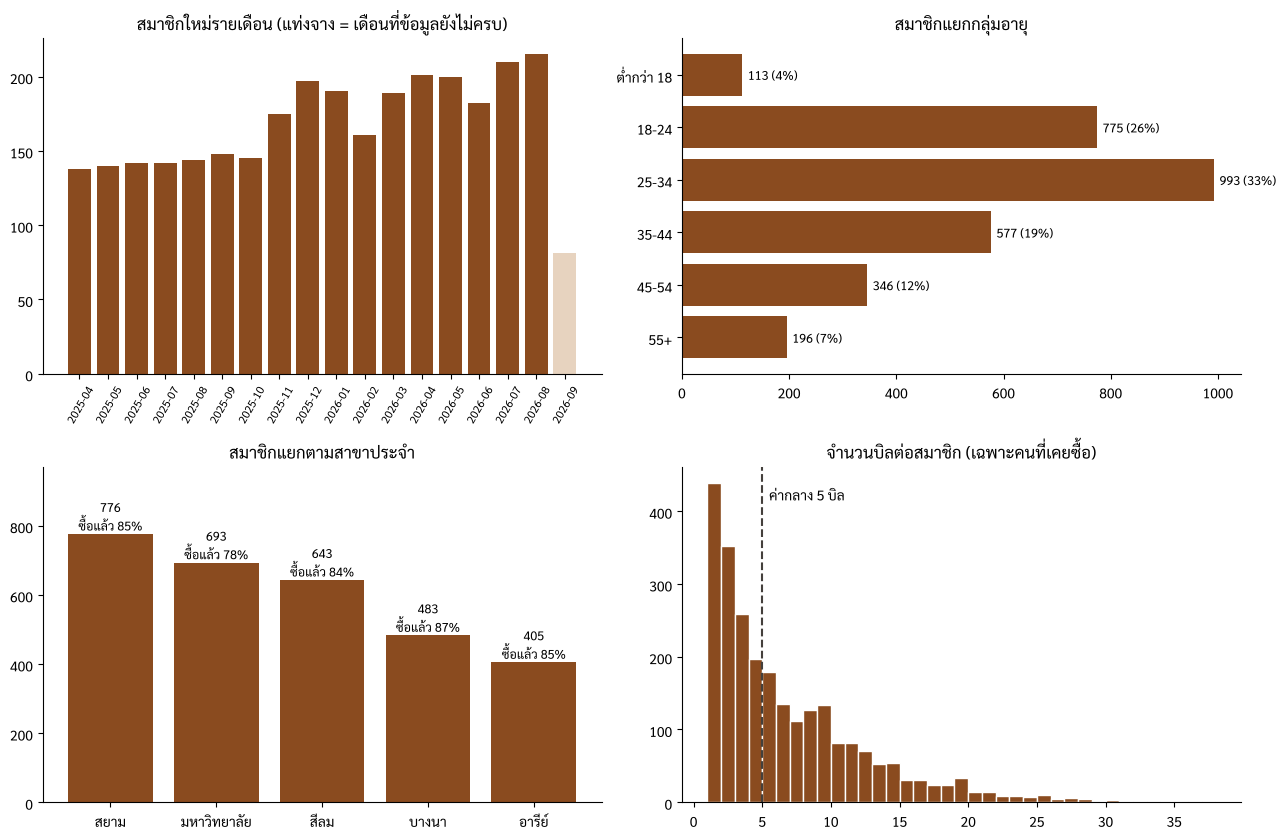

In [10]:
fig, ax = plt.subplots(2, 2, figsize=(13, 8.5))

# 1) สมาชิกใหม่รายเดือน · เดือนล่าสุดข้อมูลไม่ครบ ใช้สีจาง (บทเรียนจากกราฟ 4 ใน Lab 2.2)
m = clean.groupby(clean["joined_date"].str[:7]).size()
last_day = pd.to_datetime(clean["joined_date"]).max()
colors = [MUTED if k == m.index[-1] and last_day.day < 28 else MAIN for k in m.index]
ax[0, 0].bar(m.index, m.values, color=colors)
ax[0, 0].set_title("สมาชิกใหม่รายเดือน (แท่งจาง = เดือนที่ข้อมูลยังไม่ครบ)")
ax[0, 0].tick_params(axis="x", rotation=60, labelsize=8)

# 2) กลุ่มอายุ เรียงตามอายุ (ข้อมูลมีลำดับ จึงไม่เรียงตามจำนวน)
a = clean["age_group"].value_counts().reindex(AGES)
ax[0, 1].barh(a.index, a.values, color=MAIN); ax[0, 1].invert_yaxis()
for i, v in enumerate(a.values): ax[0, 1].text(v + 10, i, f"{v:,} ({v/n:.0%})", va="center", fontsize=9)
ax[0, 1].set_title("สมาชิกแยกกลุ่มอายุ")

# 3) สาขาประจำ: จำนวนสมาชิก + % ที่เคยซื้อ
b = clean.groupby("branch").agg(members=("customer_id", "size"), active=("has_purchase", "mean")).sort_values("members", ascending=False)
ax[1, 0].bar(b.index, b["members"], color=MAIN)
for i, (mem, act) in enumerate(zip(b["members"], b["active"])): ax[1, 0].text(i, mem + 10, f"{mem:,}\nซื้อแล้ว {act:.0%}", ha="center", fontsize=9)
ax[1, 0].set_title("สมาชิกแยกตามสาขาประจำ"); ax[1, 0].set_ylim(0, b["members"].max() * 1.25)

# 4) จำนวนบิลต่อสมาชิก (histogram) เห็นว่าเบ้ขวา ค่าเฉลี่ยจึงสูงกว่าค่ากลาง
bills = clean.loc[clean.has_purchase, "bills"]
ax[1, 1].hist(bills, bins=range(1, bills.max() + 2), color=MAIN, edgecolor="white")
ax[1, 1].axvline(bills.median(), color="#44403c", ls="--"); ax[1, 1].text(bills.median() + 0.5, ax[1, 1].get_ylim()[1] * 0.9, f"ค่ากลาง {bills.median():.0f} บิล")
ax[1, 1].set_title("จำนวนบิลต่อสมาชิก (เฉพาะคนที่เคยซื้อ)")
plt.tight_layout(); plt.show()

### ข้อสังเกตเบื้องต้น
1. **ฐานสมาชิกโตต่อเนื่อง** สมาชิกใหม่เพิ่มจาก ~140 คน/เดือน เป็น ~200 คน/เดือน หลังเปิดสาขาอารีย์ (พ.ย. 68)
2. **กลุ่มหลักคือ 18–34 ปี** รวมกันประมาณ 59% ของสมาชิก → โปรโมชันและช่องทางสื่อสารควรเน้นกลุ่มวัยเรียน/วัยทำงานตอนต้น
3. **สมาชิก 1 ใน 6 ไม่เคยซื้อเลย** สาขามหาวิทยาลัยมีสัดส่วนสมาชิกที่เคยซื้อต่ำสุด → ทำคูปองซื้อครั้งแรกให้สมาชิกที่ยังไม่เคยซื้อ
4. **สมาชิกจ่ายต่อบิลไม่ต่างจากลูกค้าทั่วไป** แต่สร้างยอดขายเกือบครึ่งร้าน คุณค่าของสมาชิกจึงอยู่ที่ **ความถี่ในการกลับมา** ไม่ใช่ขนาดบิล

## 6) Export

In [11]:
clean.to_csv("customers_clean.csv", index=False)

# ไฟล์สำหรับ Dashboard ที่เปิดเป็นเว็บสาธารณะ: ตัดชื่อเล่นและเบอร์โทรออก (หลัก PDPA: ใช้ข้อมูลส่วนบุคคลเท่าที่จำเป็น)
public_cols = ["customer_id", "gender", "age_group", "home_branch_id", "branch", "branch_type", "joined_date"]
clean[public_cols].to_csv("customers_dashboard.csv", index=False)
print("บันทึก customers_clean.csv (", clean.shape, ") และ customers_dashboard.csv (", clean[public_cols].shape, ")")

บันทึก customers_clean.csv ( (3000, 14) ) และ customers_dashboard.csv ( (3000, 7) )
